# Why Indian Startups Fail: A Data-Driven Analysis
## Startup Survival Outcomes — Python Analysis

**Author:** [Your Name]  
**Dataset:** 62 Indian startups (curated sample, post-deduplication)  
**Tools:** Python · pandas · matplotlib · seaborn · scipy  
**Status split:** 38 Active (61.3%) · 24 Closed (38.7%)

> **Note:** This dataset is manually curated and not intended to represent the entire Indian startup ecosystem.  
> All findings are observed patterns within the sample and should not be interpreted as causal conclusions.

---

### Research Question
*What startup characteristics are most strongly associated with failure and survival outcomes among Indian startups?*

### Hypothesis
Funding level and industry characteristics are associated with startup survival outcomes in India, with lower-funded startups exhibiting higher failure rates than heavily funded startups.

---
### Table of Contents
1. [Imports & Setup](#1-imports--setup)  
2. [Load & Clean Data](#2-load--clean-data)  
3. [Exploratory Data Analysis](#3-exploratory-data-analysis)  
4. [Statistical Analysis](#4-statistical-analysis)  
5. [Visualisations](#5-visualisations)  
6. [Hypothesis Verdict](#6-hypothesis-verdict)  
7. [Key Findings](#7-key-findings)


## 1. Imports & Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
from scipy.stats import pointbiserialr, chi2_contingency, mannwhitneyu, kruskal

warnings.filterwarnings('ignore')

# ── Colour palette (dark theme) ──────────────────────────────────────────────
BG      = "#0F1117"
CARD    = "#1A1D27"
ACCENT1 = "#6C63FF"   # violet
ACCENT2 = "#FF6584"   # coral  (failures)
ACCENT3 = "#43E8A0"   # mint   (active / positive)
ACCENT4 = "#FFD166"   # amber  (warnings / outliers)
ACCENT5 = "#4FC3F7"   # sky    (neutral)
TEXT_HI  = "#FFFFFF"
TEXT_MID = "#B0B8C8"
GRID     = "#252836"

plt.rcParams.update({
    'figure.facecolor'  : BG,
    'axes.facecolor'    : CARD,
    'axes.edgecolor'    : GRID,
    'axes.labelcolor'   : TEXT_MID,
    'xtick.color'       : TEXT_MID,
    'ytick.color'       : TEXT_MID,
    'text.color'        : TEXT_HI,
    'grid.color'        : GRID,
    'grid.linewidth'    : 0.6,
    'font.family'       : 'DejaVu Sans',
    'axes.spines.top'   : False,
    'axes.spines.right' : False,
})

FUNDING_ORDER = ['very low', 'low', 'medium', 'high', 'very high']
print("Libraries loaded successfully.")


Libraries loaded successfully.


## 2. Load & Clean Data

### 2.1 Load Raw Data

The raw CSV contains 66 rows. Four startups appear twice (CoinSwitch, CoinDCX, BlackBuck, Livspace).  
We keep the first occurrence of each and drop the duplicate, leaving **62 unique startups**.


In [2]:
df_raw = pd.read_csv('/mnt/data/startup_python(1).csv')
print(f"Raw shape: {df_raw.shape}")
print(df_raw.head())


Raw shape: (66, 9)
      startup  year founded  ... outcome category survival years
0    blusmart          2019  ...           failed              6
1       astra          2023  ...           failed              2
2    beepkart          2020  ...           failed              5
3  bharatagri          2017  ...           failed              8
4  builder.ai          2012  ...           failed             13

[5 rows x 9 columns]


### 2.2 Clean & Encode

In [3]:
# Rename columns
df = df_raw.copy()
df.columns = ['startup', 'year_founded', 'industry', 'funding_range',
               'funding_stage', 'status', 'unicorn', 'outcome', 'survival_years']

# Strip whitespace and lowercase all string fields
for col in ['startup', 'industry', 'funding_range', 'funding_stage', 'status', 'outcome']:
    df[col] = df[col].str.strip().str.lower()

# Drop duplicates — keep first occurrence
df = df.drop_duplicates(subset='startup', keep='first')

# Ordinal encoding for funding range
funding_map = {'very low': 1, 'low': 2, 'medium': 3, 'high': 4, 'very high': 5}
df['funding_score'] = df['funding_range'].map(funding_map)

# Apply ordered categorical for correct sort order in plots
df['funding_range'] = pd.Categorical(df['funding_range'], categories=FUNDING_ORDER, ordered=True)

# Binary outcome columns
df['is_active'] = (df['status'] == 'active').astype(int)
df['is_closed'] = (df['status'] == 'closed').astype(int)

print(f"Clean shape: {df.shape}")
print(f"Nulls:\n{df.isnull().sum()}")


Clean shape: (62, 12)
Nulls:
startup           0
year_founded      0
industry          0
funding_range     0
funding_stage     0
status            0
unicorn           0
outcome           0
survival_years    0
funding_score     0
is_active         0
is_closed         0
dtype: int64


### 2.3 Dataset Overview

In [4]:
print("=" * 50)
print("STATUS BREAKDOWN")
print("=" * 50)
print(df['status'].value_counts())
print(f"\nOverall failure rate: {df['is_closed'].mean()*100:.1f}%")

print("\n" + "=" * 50)
print("FUNDING RANGE DISTRIBUTION")
print("=" * 50)
print(df['funding_range'].value_counts().sort_index())

print("\n" + "=" * 50)
print("INDUSTRY DISTRIBUTION")
print("=" * 50)
print(df['industry'].value_counts())

print("\n" + "=" * 50)
print("UNICORNS")
print("=" * 50)
print(f"Total unicorns: {df['unicorn'].sum()}")
print(f"Unicorn rate among active startups: {df[df['status']=='active']['unicorn'].mean()*100:.1f}%")


STATUS BREAKDOWN
status
active    38
closed    24
Name: count, dtype: int64

Overall failure rate: 38.7%

FUNDING RANGE DISTRIBUTION
funding_range
very low      2
low           9
medium       15
high         23
very high    13
Name: count, dtype: int64

INDUSTRY DISTRIBUTION
industry
fintech       15
e-commerce    14
saas           8
agritech       5
edtech         5
spacetech      4
healthtech     4
logistics      4
mobility       2
cleantech      1
Name: count, dtype: int64

UNICORNS
Total unicorns: 20
Unicorn rate among active startups: 52.6%


## 3. Exploratory Data Analysis

### 3.1 Years of Operation by Status

In [5]:
surv = df.groupby('status')['survival_years'].describe().round(2)
print(surv)
print()
print("Note: Active startups are still operating. These figures represent accumulated")
print("years to date, not final lifespan (right-censored data).")


        count  mean   std  min   25%  50%  75%   max
status                                              
active   38.0  7.61  1.99  4.0  6.25  8.0  9.0  10.0
closed   24.0  5.29  3.21  2.0  3.00  4.5  6.5  13.0

Note: Active startups are still operating. These figures represent accumulated
years to date, not final lifespan (right-censored data).


### 3.2 Failure Rate by Funding Range

In [6]:
fund_summary = df.groupby('funding_range', observed=True).apply(
    lambda x: pd.Series({
        'Total'        : len(x),
        'Active'       : (x['status'] == 'active').sum(),
        'Closed'       : (x['status'] == 'closed').sum(),
        'Failure Rate' : f"{(x['status'] == 'closed').mean()*100:.1f}%"
    })
).reset_index()
print(fund_summary.to_string(index=False))


funding_range  Total  Active  Closed Failure Rate
     very low      2       0       2       100.0%
          low      9       0       9       100.0%
       medium     15       9       6        40.0%
         high     23      20       3        13.0%
    very high     13       9       4        30.8%


### 3.3 Failure Rate by Industry

In [7]:
ind_summary = df.groupby('industry').apply(
    lambda x: pd.Series({
        'n'            : len(x),
        'Closed'       : (x['status'] == 'closed').sum(),
        'Failure Rate' : f"{(x['status'] == 'closed').mean()*100:.1f}%",
        'Unicorns'     : x['unicorn'].sum()
    })
).reset_index().sort_values('n', ascending=False)
print(ind_summary.to_string(index=False))
print()
print("⚠  Cleantech (n=1) is excluded from interpretation — insufficient sample size.")


  industry  n  Closed Failure Rate  Unicorns
   fintech 15       5        33.3%         5
e-commerce 14       3        21.4%         9
      saas  8       3        37.5%         1
  agritech  5       2        40.0%         0
    edtech  5       3        60.0%         2
healthtech  4       3        75.0%         0
 spacetech  4       1        25.0%         0
 logistics  4       2        50.0%         2
  mobility  2       1        50.0%         1
 cleantech  1       1       100.0%         0

⚠  Cleantech (n=1) is excluded from interpretation — insufficient sample size.


### 3.4 Failure Rate by Funding Stage

In [8]:
stage_order = ['seed', 'series a', 'series b', 'series c+']
stage_summary = df.groupby('funding_stage').apply(
    lambda x: pd.Series({
        'n'            : len(x),
        'Failure Rate' : f"{(x['status'] == 'closed').mean()*100:.1f}%"
    })
).reindex(stage_order).reset_index()
print(stage_summary.to_string(index=False))


funding_stage  n Failure Rate
         seed  9       100.0%
     series a  8        87.5%
     series b 10        30.0%
    series c+ 35        14.3%


## 4. Statistical Analysis

Four statistical tests are applied to assess the relationship between funding, industry, and survival outcomes.  
Non-parametric tests are used throughout given the sample size (n=62) and the ordinal/categorical nature of key variables.


In [9]:
print("=" * 60)
print("TEST 1 — Point-Biserial Correlation")
print("Funding Score vs Active Status")
print("=" * 60)
r, p = pointbiserialr(df['funding_score'], df['is_active'])
print(f"r = {r:.4f}  |  p = {p:.4f}")
print("Interpretation: Moderate-to-strong positive association.")
print("Higher funding correlates with being active, but ~51% of")
print("variance in outcomes is explained by other factors.\n")

print("=" * 60)
print("TEST 2 — Chi-Square Test")
print("Funding Range vs Startup Status")
print("=" * 60)
ct = pd.crosstab(df['funding_range'], df['status'])
chi2, p_chi, dof, _ = chi2_contingency(ct)
n = ct.sum().sum()
cramers_v = np.sqrt(chi2 / (n * (min(ct.shape) - 1)))
print(ct)
print(f"\nchi2 = {chi2:.4f}  |  p = {p_chi:.4f}  |  dof = {dof}")
print(f"Cramér's V = {cramers_v:.4f}  (large effect size > 0.50)")
print("Interpretation: Highly significant association with large effect.\n")

print("=" * 60)
print("TEST 3 — Mann-Whitney U Test")
print("Years of Operation: Active vs Closed")
print("=" * 60)
active_s = df[df['status'] == 'active']['survival_years']
closed_s = df[df['status'] == 'closed']['survival_years']
u_stat, p_mw = mannwhitneyu(active_s, closed_s, alternative='two-sided')
print(f"Active  — median: {active_s.median():.1f} yrs  |  std: {active_s.std():.2f}")
print(f"Closed  — median: {closed_s.median():.1f} yrs  |  std: {closed_s.std():.2f}")
print(f"U = {u_stat:.1f}  |  p = {p_mw:.4f}")
print("Interpretation: Significant difference in operating years.")
print("Active years are right-censored — final lifespans unknown.\n")

print("=" * 60)
print("TEST 4 — Kruskal-Wallis Test")
print("Years of Operation across Industries")
print("=" * 60)
groups = [df[df['industry'] == i]['survival_years'].values
          for i in df['industry'].unique()]
h_stat, p_kw = kruskal(*groups)
print(f"H = {h_stat:.4f}  |  p = {p_kw:.4f}")
print("Interpretation: No significant difference in operating years")
print("across industries. Does NOT imply industry has no effect on")
print("success/failure — the test measures duration, not outcome.")


TEST 1 — Point-Biserial Correlation
Funding Score vs Active Status
r = 0.4928  |  p = 0.0000
Interpretation: Moderate-to-strong positive association.
Higher funding correlates with being active, but ~51% of
variance in outcomes is explained by other factors.

TEST 2 — Chi-Square Test
Funding Range vs Startup Status
status         active  closed
funding_range                
very low            0       2
low                 0       9
medium              9       6
high               20       3
very high           9       4

chi2 = 24.1588  |  p = 0.0001  |  dof = 4
Cramér's V = 0.6242  (large effect size > 0.50)
Interpretation: Highly significant association with large effect.

TEST 3 — Mann-Whitney U Test
Years of Operation: Active vs Closed
Active  — median: 8.0 yrs  |  std: 1.99
Closed  — median: 4.5 yrs  |  std: 3.21
U = 674.5  |  p = 0.0015
Interpretation: Significant difference in operating years.
Active years are right-censored — final lifespans unknown.

TEST 4 — Kruskal-Wallis T

## 5. Visualisations

### Chart 1 — Startup Distribution by Industry

Shows how startups are distributed across sectors, split by active and closed status.  
Fintech (n=15) and E-commerce (n=14) are the two largest sectors, together accounting for nearly half the dataset.


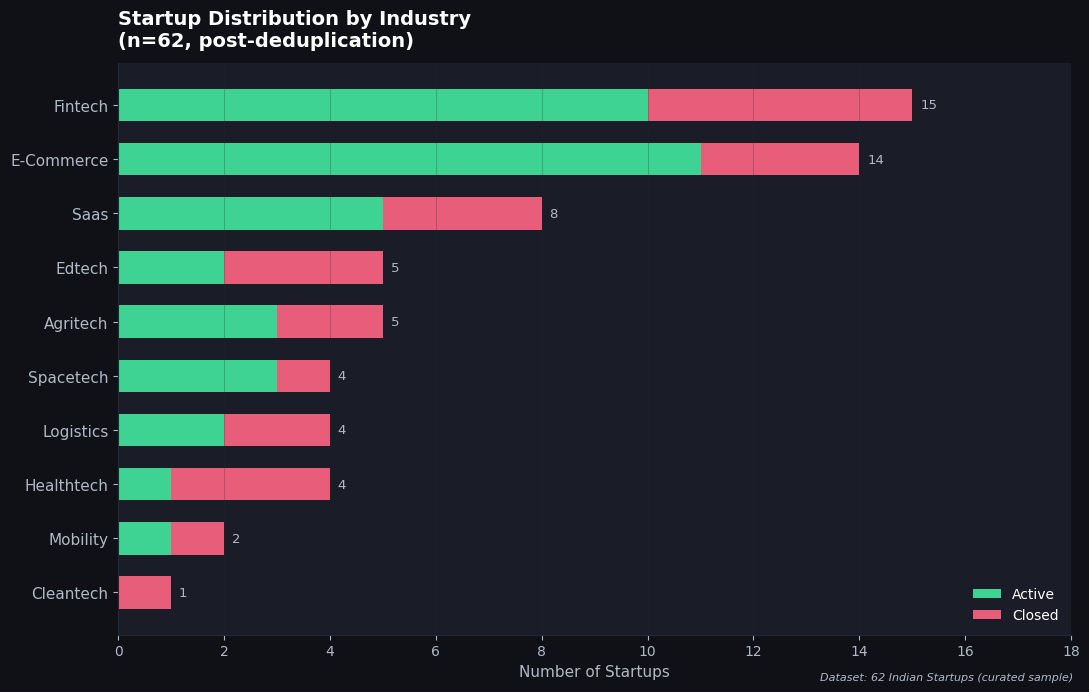

In [10]:
ind = df.groupby('industry').apply(
    lambda x: pd.Series({
        'active' : (x['status'] == 'active').sum(),
        'closed' : (x['status'] == 'closed').sum(),
        'total'  : len(x)
    })
).reset_index().sort_values('total', ascending=True)

fig, ax = plt.subplots(figsize=(11, 7), facecolor=BG)
y = np.arange(len(ind))
ax.barh(y, ind['active'], color=ACCENT3, alpha=0.9, label='Active', height=0.6)
ax.barh(y, ind['closed'], left=ind['active'], color=ACCENT2, alpha=0.9, label='Closed', height=0.6)
ax.set_yticks(y)
ax.set_yticklabels([i.title() for i in ind['industry']], fontsize=11)
ax.set_xlabel('Number of Startups', fontsize=11)
ax.set_title('Startup Distribution by Industry\n(n=62, post-deduplication)',
             fontsize=14, fontweight='bold', color=TEXT_HI, loc='left', pad=12)
for i, (a, c, t) in enumerate(zip(ind['active'], ind['closed'], ind['total'])):
    ax.text(t + 0.15, i, str(int(t)), va='center', fontsize=9.5, color=TEXT_MID)
ax.legend(fontsize=10, framealpha=0, loc='lower right')
ax.set_xlim(0, ind['total'].max() + 3)
ax.grid(axis='x', alpha=0.3)
fig.text(0.98, 0.02, 'Dataset: 62 Indian Startups (curated sample)',
         ha='right', fontsize=8, color=TEXT_MID, style='italic')
plt.tight_layout()
plt.show()


### Chart 2 — Failure Rate by Industry

Failure rates vary considerably across sectors.  
Healthtech shows the highest observed failure rate (75%), though its small sample size (n=4) requires caution.  
E-commerce exhibits the lowest failure rate (21.4%) and the highest unicorn concentration within this sample.  
Cleantech (n=1) is excluded from interpretation entirely.


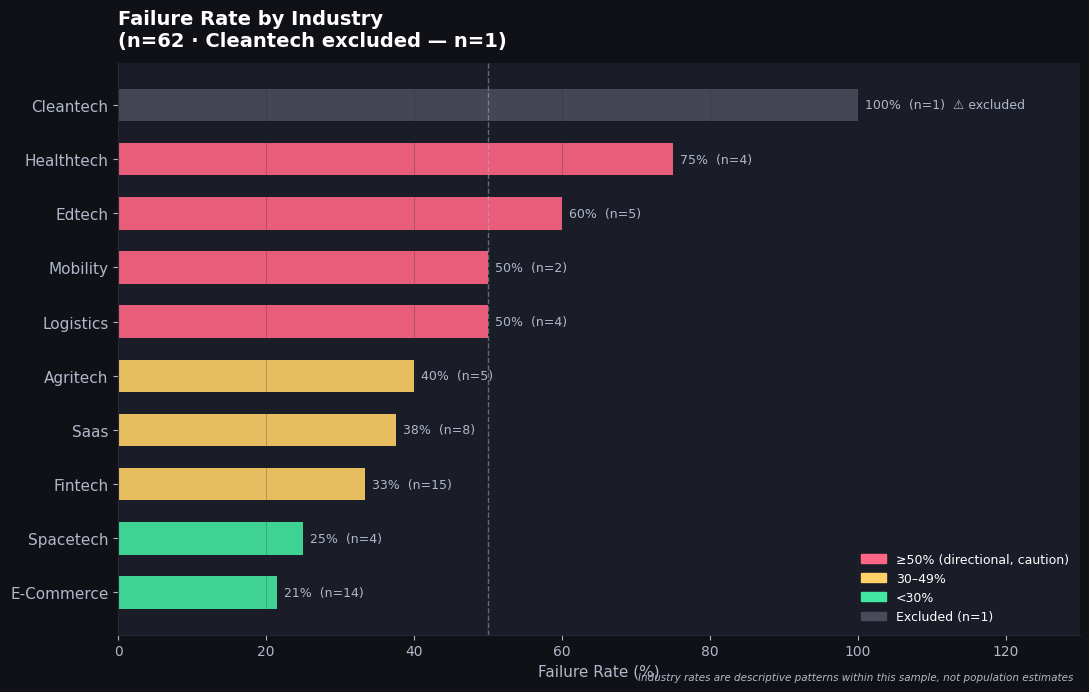

In [11]:
ind_fail = df.groupby('industry').apply(
    lambda x: pd.Series({'total': len(x),
                         'fail_rate': (x['status'] == 'closed').mean() * 100})
).reset_index().sort_values('fail_rate', ascending=True)

colors = []
for _, row in ind_fail.iterrows():
    if row['industry'] == 'cleantech':
        colors.append('#4A4A5A')
    elif row['fail_rate'] >= 50:
        colors.append(ACCENT2)
    elif row['fail_rate'] >= 30:
        colors.append(ACCENT4)
    else:
        colors.append(ACCENT3)

fig, ax = plt.subplots(figsize=(11, 7), facecolor=BG)
ax.barh(np.arange(len(ind_fail)), ind_fail['fail_rate'], color=colors, alpha=0.9, height=0.6)
ax.set_yticks(np.arange(len(ind_fail)))
ax.set_yticklabels([i.title() for i in ind_fail['industry']], fontsize=11)
ax.axvline(50, color=TEXT_MID, linestyle='--', linewidth=1, alpha=0.5)
ax.set_xlabel('Failure Rate (%)', fontsize=11)
ax.set_title('Failure Rate by Industry\n(n=62 · Cleantech excluded — n=1)',
             fontsize=14, fontweight='bold', color=TEXT_HI, loc='left', pad=12)
for i, (v, n) in enumerate(zip(ind_fail['fail_rate'], ind_fail['total'])):
    label = f"{v:.0f}%  (n={int(n)})"
    if ind_fail.iloc[i]['industry'] == 'cleantech':
        label += '  ⚠ excluded'
    ax.text(v + 1, i, label, va='center', fontsize=9, color=TEXT_MID)
ax.set_xlim(0, 130)
ax.grid(axis='x', alpha=0.3)
p1 = mpatches.Patch(color=ACCENT2, label='≥50% (directional, caution)')
p2 = mpatches.Patch(color=ACCENT4, label='30–49%')
p3 = mpatches.Patch(color=ACCENT3, label='<30%')
p4 = mpatches.Patch(color='#4A4A5A', label='Excluded (n=1)')
ax.legend(handles=[p1, p2, p3, p4], fontsize=9, framealpha=0, loc='lower right')
fig.text(0.98, 0.02,
         'Industry rates are descriptive patterns within this sample, not population estimates',
         ha='right', fontsize=7.5, color=TEXT_MID, style='italic')
plt.tight_layout()
plt.show()


### Chart 3 — Funding Range vs Startup Status

As funding level increases, the number of active startups rises and closures decline.  
The chi-square test confirms this association is statistically significant (χ²=24.16, p=0.0001, Cramér's V=0.62).  
However, the Very High category still shows a 30.8% failure rate — higher than the High category (13.0%) — 
indicating that maximum capital does not eliminate failure risk.


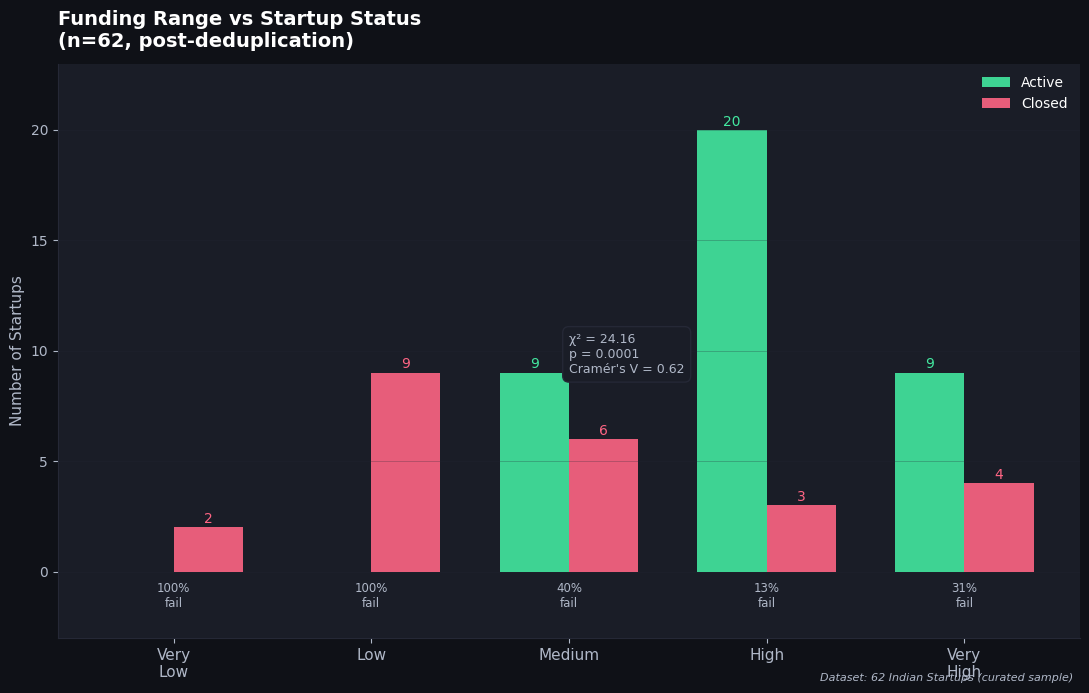

In [12]:
fund = df.groupby('funding_range', observed=True).apply(
    lambda x: pd.Series({
        'active'    : (x['status'] == 'active').sum(),
        'closed'    : (x['status'] == 'closed').sum(),
        'fail_rate' : (x['status'] == 'closed').mean() * 100
    })
).reset_index()

fig, ax = plt.subplots(figsize=(11, 7), facecolor=BG)
x = np.arange(len(fund))
w = 0.35
ax.bar(x - w/2, fund['active'], width=w, color=ACCENT3, alpha=0.9, label='Active')
ax.bar(x + w/2, fund['closed'], width=w, color=ACCENT2, alpha=0.9, label='Closed')
ax.set_xticks(x)
ax.set_xticklabels([f.replace(' ', '\n').title() for f in fund['funding_range']], fontsize=11)
ax.set_ylabel('Number of Startups', fontsize=11)
ax.set_title('Funding Range vs Startup Status\n(n=62, post-deduplication)',
             fontsize=14, fontweight='bold', color=TEXT_HI, loc='left', pad=12)
for i, (a, c, fr) in enumerate(zip(fund['active'], fund['closed'], fund['fail_rate'])):
    if a > 0: ax.text(i - w/2, a + 0.2, str(int(a)), ha='center', fontsize=10, color=ACCENT3)
    if c > 0: ax.text(i + w/2, c + 0.2, str(int(c)), ha='center', fontsize=10, color=ACCENT2)
    ax.text(i, -1.6, f"{fr:.0f}%\nfail", ha='center', fontsize=8.5, color=TEXT_MID)
ax.annotate("χ² = 24.16\np = 0.0001\nCramér's V = 0.62",
            xy=(2, 9), fontsize=9, color=TEXT_MID,
            bbox=dict(boxstyle='round,pad=0.5', facecolor=CARD, edgecolor=GRID))
ax.legend(fontsize=10, framealpha=0)
ax.grid(axis='y', alpha=0.3)
ax.set_ylim(-3, fund['active'].max() + 3)
fig.text(0.98, 0.02, 'Dataset: 62 Indian Startups (curated sample)',
         ha='right', fontsize=8, color=TEXT_MID, style='italic')
plt.tight_layout()
plt.show()


### Chart 4 — Unicorn Distribution by Industry

All 20 unicorns in this dataset originated from the High or Very High funding categories.  
E-commerce (9 unicorns) and Fintech (5 unicorns) account for the majority.  
No unicorns were produced from Low or Very Low funding categories within this sample —  
though this observation is limited to the dataset and should not be generalised.


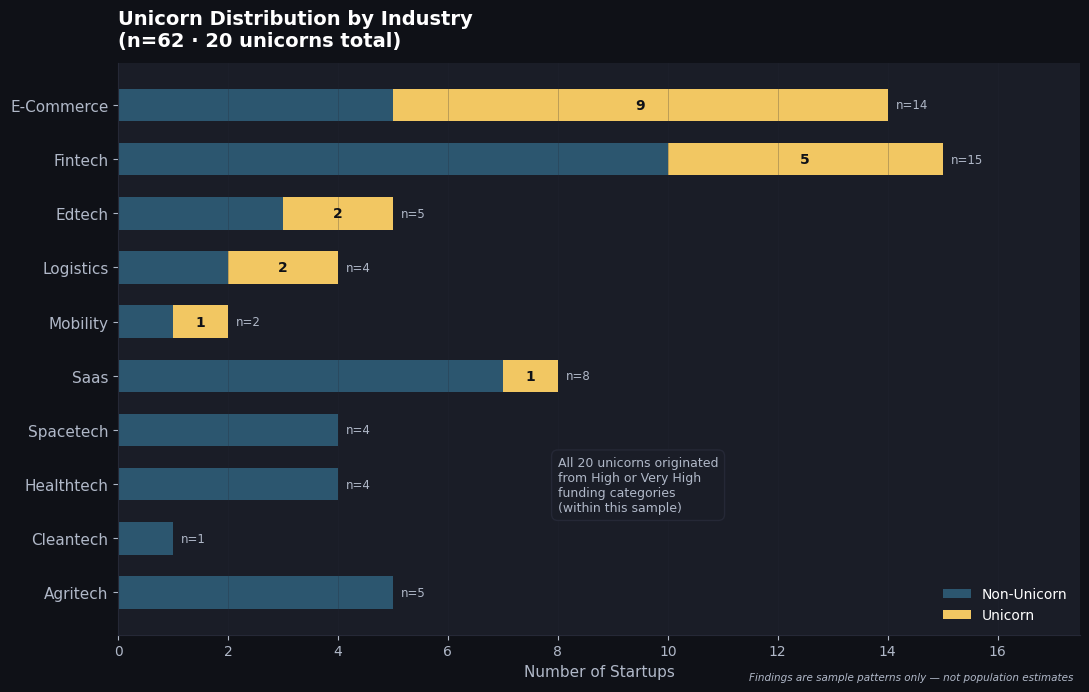

In [13]:
uni = df.groupby('industry').agg(
    total=('startup', 'count'), unicorns=('unicorn', 'sum')
).reset_index()
uni['non_uni'] = uni['total'] - uni['unicorns']
uni = uni.sort_values('unicorns', ascending=True)

fig, ax = plt.subplots(figsize=(11, 7), facecolor=BG)
y = np.arange(len(uni))
ax.barh(y, uni['non_uni'], color=ACCENT5, alpha=0.35, height=0.6, label='Non-Unicorn')
ax.barh(y, uni['unicorns'], left=uni['non_uni'], color=ACCENT4, alpha=0.95,
        height=0.6, label='Unicorn')
ax.set_yticks(y)
ax.set_yticklabels([i.title() for i in uni['industry']], fontsize=11)
ax.set_xlabel('Number of Startups', fontsize=11)
ax.set_title('Unicorn Distribution by Industry\n(n=62 · 20 unicorns total)',
             fontsize=14, fontweight='bold', color=TEXT_HI, loc='left', pad=12)
for i, (nu, u) in enumerate(zip(uni['non_uni'], uni['unicorns'])):
    if u > 0:
        ax.text(nu + u / 2, i, str(int(u)), ha='center', va='center',
                fontsize=10, fontweight='bold', color=BG)
    ax.text(nu + u + 0.15, i, f"n={int(nu + u)}", va='center', fontsize=8.5, color=TEXT_MID)
ax.legend(fontsize=10, framealpha=0, loc='lower right')
ax.grid(axis='x', alpha=0.3)
ax.set_xlim(0, uni['total'].max() + 2.5)
ax.text(8, 1.5,
        "All 20 unicorns originated\nfrom High or Very High\nfunding categories\n(within this sample)",
        fontsize=9, color=TEXT_MID,
        bbox=dict(boxstyle='round,pad=0.5', facecolor=CARD, edgecolor=GRID))
fig.text(0.98, 0.02,
         'Findings are sample patterns only — not population estimates',
         ha='right', fontsize=7.5, color=TEXT_MID, style='italic')
plt.tight_layout()
plt.show()


### Chart 5 — Funding Range Distribution with Failure Rate Overlay

High funding is the most common category (n=23, 37.1%).  
The overlaid line shows that failure rate drops sharply as funding increases —  
from 100% at Very Low/Low to 13.0% at High.  
The slight uptick at Very High (30.8%) is worth noting and is explored further in the scatter plot.


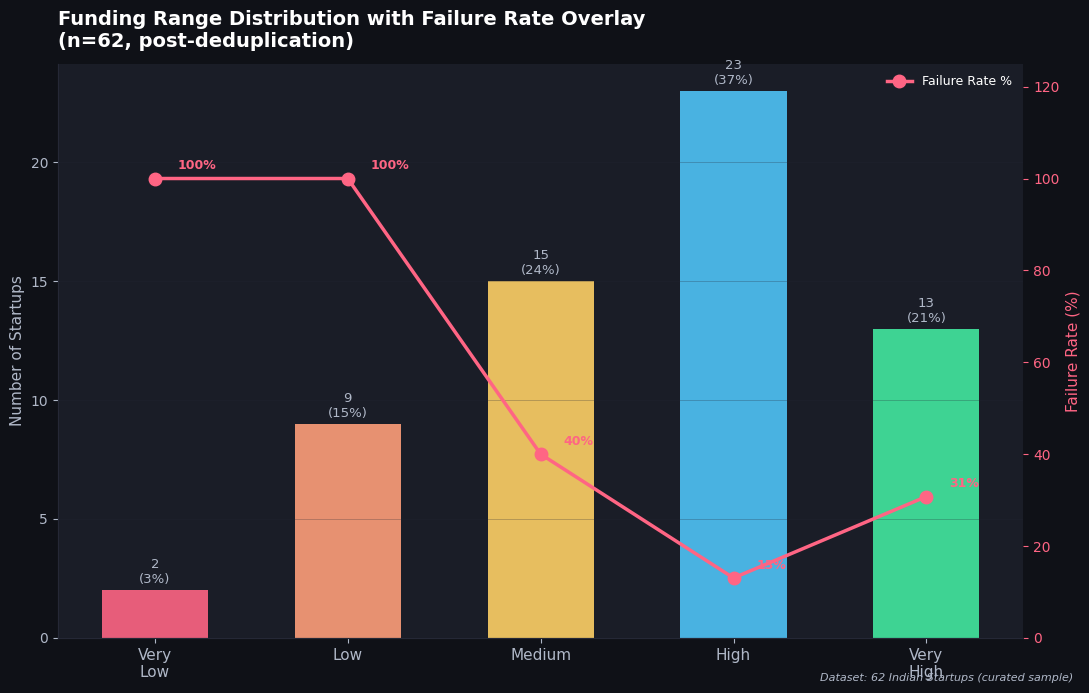

In [14]:
fund_counts = df['funding_range'].value_counts().reindex(FUNDING_ORDER)
fail_rates  = df.groupby('funding_range', observed=True).apply(
    lambda x: (x['status'] == 'closed').mean() * 100
).reindex(FUNDING_ORDER).values
bar_colors  = [ACCENT2, '#FF9F7A', ACCENT4, ACCENT5, ACCENT3]
total       = len(df)

fig, ax1 = plt.subplots(figsize=(11, 7), facecolor=BG)
ax1.bar(range(len(FUNDING_ORDER)), fund_counts.values, color=bar_colors, alpha=0.9, width=0.55)
ax1.set_xticks(range(len(FUNDING_ORDER)))
ax1.set_xticklabels([f.replace(' ', '\n').title() for f in FUNDING_ORDER], fontsize=11)
ax1.set_ylabel('Number of Startups', fontsize=11)
ax1.set_title('Funding Range Distribution with Failure Rate Overlay\n(n=62, post-deduplication)',
              fontsize=14, fontweight='bold', color=TEXT_HI, loc='left', pad=12)
for i, v in enumerate(fund_counts.values):
    ax1.text(i, v + 0.3, f"{v}\n({v/total*100:.0f}%)", ha='center', fontsize=9.5, color=TEXT_MID)
ax1.grid(axis='y', alpha=0.3)

ax2 = ax1.twinx()
ax2.plot(range(len(FUNDING_ORDER)), fail_rates, color=ACCENT2, marker='o',
         linewidth=2.5, markersize=9, zorder=5, label='Failure Rate %')
for i, fr in enumerate(fail_rates):
    ax2.text(i + 0.12, fr + 2, f"{fr:.0f}%", fontsize=9, color=ACCENT2, fontweight='bold')
ax2.set_ylabel('Failure Rate (%)', color=ACCENT2, fontsize=11)
ax2.tick_params(axis='y', colors=ACCENT2)
ax2.spines['right'].set_color(ACCENT2)
ax2.set_ylim(0, 125)
ax2.legend(loc='upper right', fontsize=9, framealpha=0)
fig.text(0.98, 0.02, 'Dataset: 62 Indian Startups (curated sample)',
         ha='right', fontsize=8, color=TEXT_MID, style='italic')
plt.tight_layout()
plt.show()


### Chart 6 — Years of Operation: Active vs Closed (Violin + Strip Plot)

Active startups have a compressed distribution (median 8 yrs, std 1.99) —  
most cluster between 6 and 10 years of operation.  
Closed startups show much wider variance (median 4.5 yrs, std 3.21),  
ranging from 2 years to 13 years before closure.

The Mann-Whitney U test confirms a statistically significant difference (p=0.0015).  
**Important:** Active startup values are right-censored — they are still operating,  
so these figures represent accumulated years to date, not final lifespan.


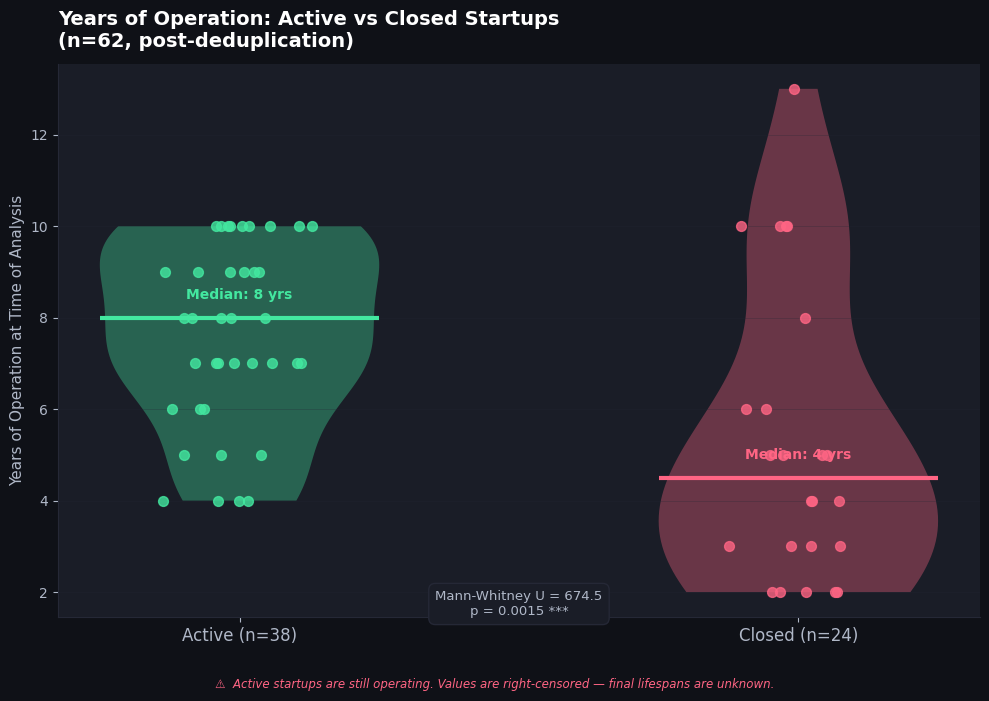

In [15]:
active_s = df[df['status'] == 'active']['survival_years'].values
closed_s = df[df['status'] == 'closed']['survival_years'].values

fig, ax = plt.subplots(figsize=(10, 7), facecolor=BG)
vp = ax.violinplot([active_s, closed_s], positions=[1, 2],
                   showmedians=False, showextrema=False)
for body, col in zip(vp['bodies'], [ACCENT3, ACCENT2]):
    body.set_facecolor(col)
    body.set_alpha(0.35)

np.random.seed(42)
ax.scatter(np.random.normal(1, 0.07, len(active_s)), active_s,
           color=ACCENT3, alpha=0.8, s=50, zorder=3)
ax.scatter(np.random.normal(2, 0.07, len(closed_s)), closed_s,
           color=ACCENT2, alpha=0.8, s=50, zorder=3)
ax.hlines(np.median(active_s), 0.75, 1.25, color=ACCENT3, linewidth=3, zorder=4)
ax.hlines(np.median(closed_s), 1.75, 2.25, color=ACCENT2, linewidth=3, zorder=4)
ax.text(1, np.median(active_s) + 0.4, f'Median: {np.median(active_s):.0f} yrs',
        ha='center', fontsize=10, color=ACCENT3, fontweight='bold')
ax.text(2, np.median(closed_s) + 0.4, f'Median: {np.median(closed_s):.0f} yrs',
        ha='center', fontsize=10, color=ACCENT2, fontweight='bold')
ax.set_xticks([1, 2])
ax.set_xticklabels(['Active (n=38)', 'Closed (n=24)'], fontsize=12)
ax.set_ylabel('Years of Operation at Time of Analysis', fontsize=11)
ax.set_title('Years of Operation: Active vs Closed Startups\n(n=62, post-deduplication)',
             fontsize=14, fontweight='bold', color=TEXT_HI, loc='left', pad=12)
ax.text(1.5, 1.5, 'Mann-Whitney U = 674.5\np = 0.0015 ***', ha='center', fontsize=9.5,
        color=TEXT_MID, bbox=dict(boxstyle='round,pad=0.5', facecolor=CARD, edgecolor=GRID))
ax.grid(axis='y', alpha=0.3)
fig.text(0.5, 0.01,
         '⚠  Active startups are still operating. Values are right-censored — '
         'final lifespans are unknown.',
         ha='center', fontsize=8.5, color=ACCENT2, style='italic')
plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.show()


### Chart 7 — Funding Score vs Years of Operation (Scatter + Regression)

Confirms the directional relationship: higher funding score is associated with more years of operation.  
Regression lines show both active and closed startups trend upward with funding level.  
Labelled outliers (Builder.ai, Dunzo, Good Glamm) are high-funded startups that still failed —  
underscoring that capital is necessary but not sufficient for survival.

Active startup years are right-censored and should not be interpreted as final lifespans.


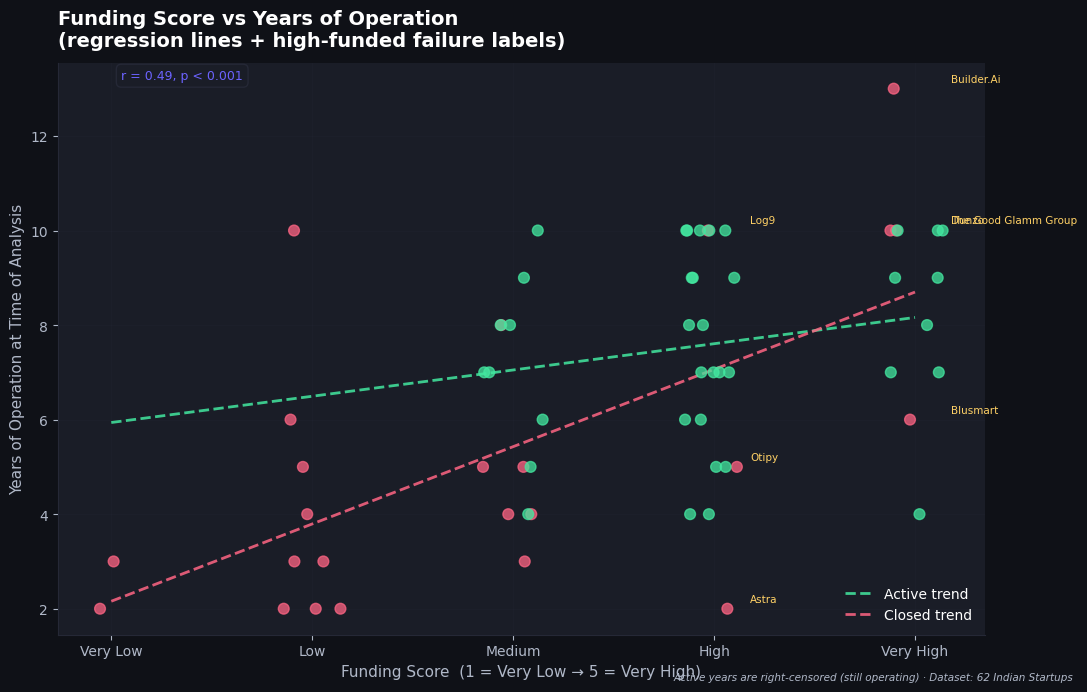

In [16]:
jitter = np.random.RandomState(1).uniform(-0.15, 0.15, len(df))
colors = [ACCENT3 if s == 'active' else ACCENT2 for s in df['status']]

fig, ax = plt.subplots(figsize=(11, 7), facecolor=BG)
ax.scatter(df['funding_score'] + jitter, df['survival_years'],
           c=colors, alpha=0.75, s=60, zorder=3)

for status, col, lbl in [('active', ACCENT3, 'Active'), ('closed', ACCENT2, 'Closed')]:
    sub = df[df['status'] == status]
    m, b = np.polyfit(sub['funding_score'], sub['survival_years'], 1)
    xs = np.linspace(1, 5, 100)
    ax.plot(xs, m * xs + b, color=col, linewidth=2, linestyle='--',
            alpha=0.85, label=f'{lbl} trend')

outliers = df[(df['funding_score'] >= 4) & (df['status'] == 'closed')]
for idx, row in outliers.iterrows():
    ax.annotate(row['startup'].title(),
                xy=(row['funding_score'] + jitter[df.index.get_loc(idx)], row['survival_years']),
                xytext=(row['funding_score'] + 0.18, row['survival_years'] + 0.15),
                fontsize=7.5, color=ACCENT4)

ax.set_xlabel('Funding Score  (1 = Very Low → 5 = Very High)', fontsize=11)
ax.set_ylabel('Years of Operation at Time of Analysis', fontsize=11)
ax.set_title('Funding Score vs Years of Operation\n(regression lines + high-funded failure labels)',
             fontsize=14, fontweight='bold', color=TEXT_HI, loc='left', pad=12)
ax.set_xticks([1, 2, 3, 4, 5])
ax.set_xticklabels(['Very Low', 'Low', 'Medium', 'High', 'Very High'], fontsize=10)
ax.legend(fontsize=10, framealpha=0)
ax.grid(alpha=0.3)
ax.text(1.05, 13.2, 'r = 0.49, p < 0.001',
        fontsize=9, color=ACCENT1,
        bbox=dict(boxstyle='round,pad=0.4', facecolor=CARD, edgecolor=GRID))
fig.text(0.98, 0.02,
         'Active years are right-censored (still operating) · Dataset: 62 Indian Startups',
         ha='right', fontsize=7.5, color=TEXT_MID, style='italic')
plt.tight_layout()
plt.show()


### Chart 8 — Failure Rate by Funding Stage

The most pronounced pattern in the dataset.  
Failure rate drops from 100% (Seed) → 87.5% (Series A) → 30.0% (Series B) → 14.3% (Series C+).  
The Series A to Series B transition represents the steepest decline,  
suggesting that reaching Series B may be a meaningful survival threshold —  
likely reflecting demonstrated product-market fit or operational viability.  
Note that early-stage sample sizes are small (Seed n=9, Series A n=8).


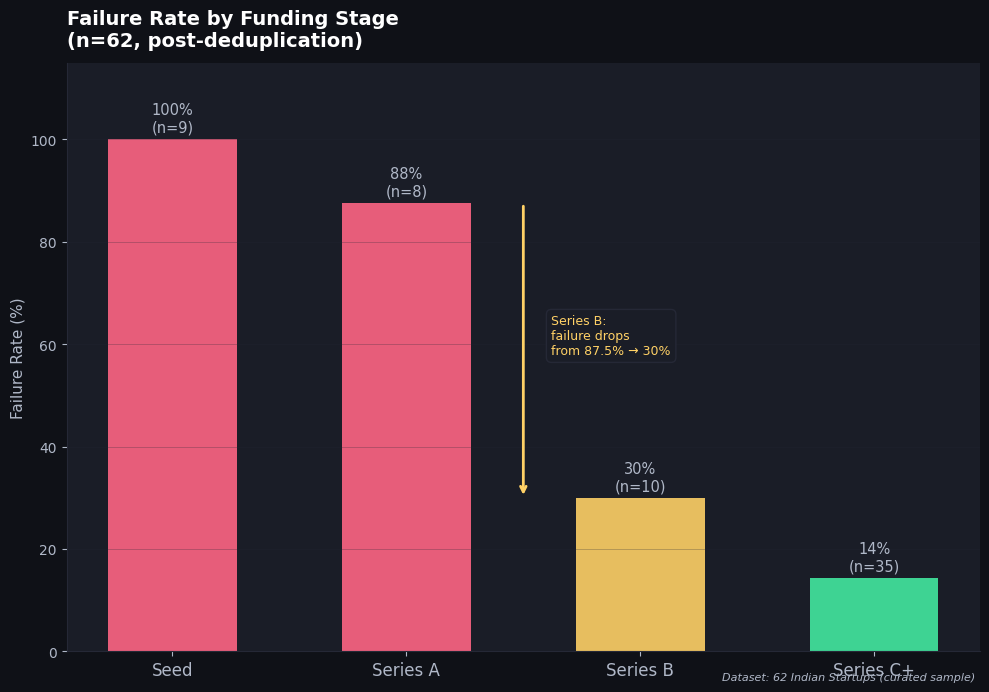

In [17]:
stage_order = ['seed', 'series a', 'series b', 'series c+']
stage_stats = df.groupby('funding_stage').apply(
    lambda x: pd.Series({'total': len(x),
                         'fail_rate': (x['status'] == 'closed').mean() * 100})
).reset_index()
stage_stats['funding_stage'] = pd.Categorical(
    stage_stats['funding_stage'], categories=stage_order, ordered=True)
stage_stats = stage_stats.sort_values('funding_stage')
colors = [ACCENT2 if r >= 50 else ACCENT4 if r >= 25 else ACCENT3
          for r in stage_stats['fail_rate']]

fig, ax = plt.subplots(figsize=(10, 7), facecolor=BG)
ax.bar(range(len(stage_stats)), stage_stats['fail_rate'],
       color=colors, alpha=0.9, width=0.55)
ax.set_xticks(range(len(stage_stats)))
ax.set_xticklabels([s.title() for s in stage_stats['funding_stage']], fontsize=12)
ax.set_ylabel('Failure Rate (%)', fontsize=11)
ax.set_ylim(0, 115)
ax.set_title('Failure Rate by Funding Stage\n(n=62, post-deduplication)',
             fontsize=14, fontweight='bold', color=TEXT_HI, loc='left', pad=12)
for i, (r, n) in enumerate(zip(stage_stats['fail_rate'], stage_stats['total'])):
    ax.text(i, r + 1.5, f"{r:.0f}%\n(n={int(n)})", ha='center', fontsize=10.5, color=TEXT_MID)
ax.grid(axis='y', alpha=0.3)
ax.annotate('', xy=(1.5, 30), xytext=(1.5, 87.5),
            arrowprops=dict(arrowstyle='->', color=ACCENT4, lw=2))
ax.text(1.62, 58, 'Series B:\nfailure drops\nfrom 87.5% → 30%',
        fontsize=9, color=ACCENT4,
        bbox=dict(boxstyle='round,pad=0.4', facecolor=CARD, edgecolor=GRID))
fig.text(0.98, 0.02, 'Dataset: 62 Indian Startups (curated sample)',
         ha='right', fontsize=8, color=TEXT_MID, style='italic')
plt.tight_layout()
plt.show()


## 6. Hypothesis Verdict

**Hypothesis:** *Funding level and industry characteristics are associated with startup survival outcomes in India, with lower-funded startups exhibiting higher failure rates than heavily funded startups.*

### Verdict: PARTIALLY SUPPORTED

| Component | Evidence | Verdict |
|-----------|----------|---------|
| Lower funding → higher failure | Very Low/Low = 100% failure; χ²=24.16, p=0.0001; r=0.49 | ✅ Supported (caveat: small cells) |
| Heavily funded = better survival | High funding: 13.0% failure rate | ✅ Supported |
| Heavily funded = guaranteed survival | Very High: 30.8% failure; 5 major closures | ❌ Not supported |
| Industry characteristics matter | Rates vary 21–75% descriptively | ✅ Directionally supported |
| Industry effect statistically significant | Kruskal-Wallis p=0.44 | ❌ Not statistically confirmed |

The hypothesis captures the directional pattern correctly but overstates the protective power of high funding.  
The more precise finding is: **funding is a necessary but not sufficient condition for survival.**


## 7. Key Findings

1. **Funding level is the strongest measurable predictor of survival** — r=0.49 (p<0.001), χ²=24.16 (p=0.0001), Cramér's V=0.62
2. **Very Low and Low funded startups had a 100% failure rate** in this dataset (n=2 and n=9 — treat directionally)
3. **Series B is the most pronounced survival threshold** — failure drops from 87.5% (Series A) to 30.0% (Series B)
4. **While High-funded startups exhibited lower failure rates than Very High-funded startups in this sample, several heavily funded failures indicate that capital alone does not guarantee startup survival**
5. **E-commerce exhibited the strongest survival outcomes within the sample**; Healthtech recorded the highest observed failure rate (75%), though limited by sample size (n=4)
6. **Active startups accumulated significantly more operating years** than closed startups (medians 8 vs 4.5 yrs, p=0.0015) — values are right-censored
7. **All 20 unicorns originated from High or Very High funding categories** within this sample

---

### Limitations
- The dataset represents a curated sample of 62 Indian startups and is not intended to represent the entire Indian startup ecosystem.
- Certain industries contain relatively small sample sizes, which may affect the reliability of industry-level comparisons.
- Active startups are still operating at the time of analysis. Years of operation for active startups represent accumulated years to date rather than final lifespan.
- Findings should be interpreted as observed patterns within the sample and not as causal relationships.
